# Minimal Live Pipeline: Online Bayesian Meal Response Identification

This notebook is a compact, reusable version of the Mode 2 pipeline. It is organized like a small library:

1. Dataframe -> meal-window samples.
2. Ackerman/state-space meal-response model.
3. Completed-meal A/T posterior labels.
4. Population/person kinetic estimation.
5. Premeal prior learning for A/T.
6. Online Bayesian updating of A/T during a meal.
7. Counterfactual meal recommendations.

The goal is to make each function small enough to reuse in scripts or a live reader. The final demo cell is disabled by default; set `RUN_MINIMAL_DEMO = True` when you want to run a small end-to-end example.

In [1]:
# =========================================================
# Imports and Configuration
# =========================================================

from collections import defaultdict
from pathlib import Path
from statistics import NormalDist

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from tqdm import tqdm

ROOT_DIR = Path.cwd()
if ROOT_DIR.name == "nbs":
    ROOT_DIR = ROOT_DIR.parent

DATA_PATH = ROOT_DIR / "data" / "processed" / "t2d_long_format.csv"
FEATURES_PATH = ROOT_DIR / "data" / "processed" / "extracted_features.csv"

TIME_GRID = np.arange(-30.0, 181.0, 5.0)

DEFAULT_THETA = {
    "period": 170.0,
    "zeta": 0.70,
    "k_b": 0.001,
    "A0": 0.12,
    "T0": 90.0,
    "pulse_fast_fraction": 0.58,
    "pulse_fast_width_fraction": 0.45,
    "pulse_delay_fraction": 0.30,
    "pulse_edge": 3.0,
}

PARAM_BOUNDS = {
    "A": (0.01, 0.35),
    "T": (15.0, 180.0),
    "period": (80.0, 280.0),
    "zeta": (0.25, 1.75),
}

LABEL_A_GRID = np.linspace(0.01, 0.30, 16)
LABEL_T_GRID = np.linspace(15.0, 165.0, 16)

LABEL_SIGMA = 18.0
LABEL_TEMPERATURE = 0.20
ONLINE_SIGMA = 18.0
ONLINE_EFFECTIVE_INDEPENDENT_MINUTES = 25.0
MODEL_ERROR_SIGMA = 14.0
NORMAL = NormalDist()

In [2]:
# =========================================================
# Dataframe -> Meal-Window Samples
# =========================================================

MEAL_TYPE_MAP = {
    "breakfast": np.array([1.0, 0.0, 0.0]),
    "lunch": np.array([0.0, 1.0, 0.0]),
    "dinner": np.array([0.0, 0.0, 1.0]),
}

NUTRIENT_COLUMN_MAP = {
    "kcal": "Kcal",
    "carbs": "CHO_g",
    "fat": "Fat_g",
    "protein": "Prot_g",
    "fiber": "Fiber_g",
    "sugars": "Sugars_g",
    "saturated_fat": "Saturated fat_g",
    "mufa": "MUFA_g",
    "pufa": "PUFA_g",
    "animal_protein": "Animal_Protein_g",
    "plant_protein": "Plant_protein_g",
    "glycemic_index": "Glycemic_Index",
    "glycemic_load": "Glycemic_Load",
}

PERSON_COVARIATE_COLUMNS = [
    "Age",
    "Sex",
    "BMI",
    "WC_cm",
    "HbA1c_perc",
    "Diabetes duration_years",
    "HOMA_IR",
    "Metformin use",
    "Lipid therapy",
]


def finite_float(value, default=0.0):
    try:
        value = float(value)
    except Exception:
        return float(default)
    if not np.isfinite(value):
        return float(default)
    return float(value)


def clean_response_dataframe(df):
    df = df.copy()
    df = df.drop(columns=["Unnamed: 0"], errors="ignore")
    df["Glucose"] = pd.to_numeric(df["Glucose"], errors="coerce")
    df["time_meal"] = pd.to_numeric(df["time_meal"], errors="coerce")
    df = df.dropna(subset=["Glucose", "time_meal", "abs_ID", "ID"])
    return df


def extract_meal_nutrients(group):
    row = group.iloc[0]
    meal = {}
    for key, column in NUTRIENT_COLUMN_MAP.items():
        meal[key] = finite_float(row[column], np.nan) if column in group.columns else np.nan

    carbs = finite_float(meal.get("carbs", 0.0))
    fat = finite_float(meal.get("fat", 0.0))
    protein = finite_float(meal.get("protein", 0.0))
    kcal_default = 4.0 * carbs + 9.0 * fat + 4.0 * protein
    meal["kcal"] = finite_float(meal.get("kcal", kcal_default), kcal_default)
    meal["fiber"] = finite_float(meal.get("fiber", 0.0), 0.0)
    meal["sugars"] = finite_float(meal.get("sugars", 0.0), 0.0)
    meal["glycemic_index"] = finite_float(meal.get("glycemic_index", 60.0), 60.0)
    meal["glycemic_load"] = finite_float(meal.get("glycemic_load", carbs * meal["glycemic_index"] / 100.0), carbs * meal["glycemic_index"] / 100.0)
    return meal


def load_person_covariates(features_path=FEATURES_PATH):
    if not Path(features_path).exists():
        return {}

    df = pd.read_csv(features_path)
    if "ID" not in df.columns:
        return {}

    covariates = {}
    for person_id, group in df.groupby("ID"):
        row = group.iloc[0]
        covariates[int(float(person_id))] = {
            column: row[column]
            for column in PERSON_COVARIATE_COLUMNS
            if column in group.columns
        }
    return covariates


def meal_type_vector(meal_type):
    meal_type = str(meal_type).lower()
    return MEAL_TYPE_MAP.get(meal_type, np.zeros(3, dtype=float)).copy()


def is_standardized_test_meal(sample_or_meal):
    meal_type = str(sample_or_meal.get("meal_type", "")).lower()
    meal_id = str(sample_or_meal.get("meal_id", "")).lower()
    return "test" in meal_type or "test" in meal_id


def build_meal_windows(
    df,
    t_grid=TIME_GRID,
    min_pre_time=-25.0,
    min_post_time=120.0,
    require_full_grid=True,
    person_covariates=None,
):
    """Convert the long CGM dataframe into simple sample dictionaries."""
    df = clean_response_dataframe(df)
    person_covariates = person_covariates or {}
    windows = []

    for meal_id, group in df.groupby("abs_ID"):
        group = group.sort_values("time_meal")
        time_raw = group["time_meal"].to_numpy(dtype=float)
        glucose_raw = group["Glucose"].to_numpy(dtype=float)
        ok = np.isfinite(time_raw) & np.isfinite(glucose_raw)
        time_raw = time_raw[ok]
        glucose_raw = glucose_raw[ok]
        if len(time_raw) < 8:
            continue
        if np.nanmin(time_raw) > min_pre_time or np.nanmax(time_raw) < min_post_time:
            continue
        if require_full_grid and (np.nanmin(time_raw) > np.nanmin(t_grid) or np.nanmax(time_raw) < np.nanmax(t_grid)):
            continue

        order = np.argsort(time_raw)
        time_raw = time_raw[order]
        glucose_raw = glucose_raw[order]
        glucose = np.interp(t_grid, time_raw, glucose_raw)

        person_id = int(float(group["ID"].iloc[0]))
        meal_type = str(group["Meal type"].iloc[0])
        context = np.r_[0.0, 0.0, meal_type_vector(meal_type)]

        windows.append({
            "idx": len(windows),
            "person_id": person_id,
            "original_person_id": person_id,
            "meal_id": str(meal_id),
            "meal_type": meal_type,
            "day": int(finite_float(group["Day number"].iloc[0], 0.0)) if "Day number" in group.columns else -1,
            "meal": extract_meal_nutrients(group),
            "context": context.astype(float),
            "person_covariates": person_covariates.get(person_id, {}),
            "time": np.asarray(t_grid, dtype=float),
            "glucose": np.asarray(glucose, dtype=float),
        })

    return windows


def load_live_windows(data_path=DATA_PATH, features_path=FEATURES_PATH):
    df = pd.read_csv(data_path)
    covariates = load_person_covariates(features_path)
    windows = build_meal_windows(df, person_covariates=covariates)
    return df, windows


def split_meals_by_person(windows, train_frac=0.70, min_train=5, min_test=2, random_state=0):
    rng = np.random.default_rng(random_state)
    by_person = defaultdict(list)
    for idx, sample in enumerate(windows):
        by_person[int(sample["person_id"])].append(idx)

    train_idx, test_idx = [], []
    for person_id, indices in by_person.items():
        indices = np.asarray(indices, dtype=int)
        rng.shuffle(indices)
        if len(indices) < min_train + min_test:
            continue
        n_train = int(np.clip(round(train_frac * len(indices)), min_train, len(indices) - min_test))
        train_idx.extend(indices[:n_train].tolist())
        test_idx.extend(indices[n_train:].tolist())

    return sorted(train_idx), sorted(test_idx)


def sample_with_meal(sample, meal):
    new_sample = dict(sample)
    new_sample["meal"] = dict(meal)
    return new_sample

In [3]:
# =========================================================
# Model Primitives
# =========================================================


def merge_theta(theta=None):
    merged = dict(DEFAULT_THETA)
    if theta:
        merged.update(theta)
    merged["period"] = float(np.clip(merged["period"], *PARAM_BOUNDS["period"]))
    merged["zeta"] = float(np.clip(merged["zeta"], *PARAM_BOUNDS["zeta"]))
    merged["k_b"] = float(max(0.0, merged.get("k_b", 0.001)))
    return merged


def premeal_summary(sample):
    time = np.asarray(sample["time"], dtype=float)
    glucose = np.asarray(sample["glucose"], dtype=float)
    pre = time < 0
    if np.any(pre):
        t_pre = time[pre]
        g_pre = glucose[pre]
        baseline = float(np.median(g_pre))
        slope = float(np.polyfit(t_pre, g_pre, 1)[0]) if len(t_pre) >= 2 else 0.0
        last_level = float(g_pre[-1])
        delta_30 = float(g_pre[-1] - g_pre[0]) if len(g_pre) >= 2 else 0.0
        pre_std = float(np.std(g_pre))
        pre_range = float(np.max(g_pre) - np.min(g_pre))
    else:
        baseline = float(glucose[0])
        slope = 0.0
        last_level = baseline
        delta_30 = 0.0
        pre_std = 0.0
        pre_range = 0.0

    return {
        "baseline": baseline,
        "slope": slope,
        "last_level": last_level,
        "delta_30": delta_30,
        "std": pre_std,
        "range": pre_range,
    }


def response_metrics(time, curve, baseline=None, threshold=180.0):
    time = np.asarray(time, dtype=float)
    curve = np.asarray(curve, dtype=float)
    if baseline is None:
        baseline = float(np.median(curve[time < 0])) if np.any(time < 0) else float(curve[0])
    post = time >= 0
    post_time = time[post]
    post_curve = curve[post]
    above_base = post_curve - baseline
    return {
        "baseline": float(baseline),
        "peak": float(np.max(post_curve)),
        "peak_delta": float(np.max(post_curve) - baseline),
        "iAUC": float(np.trapz(np.maximum(above_base, 0.0), post_time)) if len(post_time) else 0.0,
        "time_above_180": float(np.sum(post_curve > threshold) * np.nanmedian(np.diff(time))) if len(time) > 1 else 0.0,
    }


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.asarray(x, dtype=float)))


def finite_width_pulse(t, width, edge=3.0):
    if t < 0:
        return 0.0
    width = max(float(width), 1e-6)
    edge = max(float(edge), 1e-6)
    return float(sigmoid(t / edge) * sigmoid((width - t) / edge))


def asymmetric_meal_pulse(t, T, theta=None):
    """Two-component smooth pulse with one interpretable width parameter T."""
    theta = merge_theta(theta)
    if t < 0:
        return 0.0

    rho = float(np.clip(theta.get("pulse_fast_fraction", 0.58), 0.0, 1.0))
    fast_width = max(float(theta.get("pulse_fast_width_fraction", 0.45)) * T, 1.0)
    delay = max(float(theta.get("pulse_delay_fraction", 0.30)) * T, 0.0)
    slow_width = max(T - delay, 1.0)
    edge = float(theta.get("pulse_edge", 3.0))

    fast = finite_width_pulse(t, fast_width, edge=edge)
    slow = finite_width_pulse(t - delay, slow_width, edge=edge * 1.5)
    return rho * fast + (1.0 - rho) * slow


def rollout_meal_response(sample, theta=None, A=None, T=None):
    """Deterministic Ackerman-style rollout for one fixed A/T pair."""
    theta = merge_theta(theta)
    time = np.asarray(sample["time"], dtype=float)
    glucose = np.asarray(sample["glucose"], dtype=float)
    pre = premeal_summary(sample)

    A = DEFAULT_THETA["A0"] if A is None else float(A)
    T = DEFAULT_THETA["T0"] if T is None else float(T)
    A = float(np.clip(A, *PARAM_BOUNDS["A"]))
    T = float(np.clip(T, *PARAM_BOUNDS["T"]))

    omega = 2.0 * np.pi / theta["period"]
    zeta = theta["zeta"]
    k_b = theta["k_b"]

    # State: G deviation, V velocity, B baseline.
    state = np.array([glucose[0] - pre["baseline"], pre["slope"], pre["baseline"]], dtype=float)
    pred = []

    for i, t in enumerate(time):
        pred.append(float(state[0] + state[2]))
        if i == len(time) - 1:
            break

        dt = float(time[i + 1] - time[i])
        n_steps = max(1, int(np.ceil(abs(dt))))
        h = dt / n_steps

        for substep in range(n_steps):
            t_sub = float(t) + substep * h
            G, V, B = state
            u = A * asymmetric_meal_pulse(t_sub, T, theta=theta)
            dG = V
            dV = -(omega ** 2) * G - 2.0 * zeta * omega * V + u
            dB = -k_b * (B - pre["baseline"])
            state = np.array([G + h * dG, V + h * dV, B + h * dB], dtype=float)

    return np.asarray(pred, dtype=float)

In [4]:
# =========================================================
# Bayesian Utilities and Completed-Meal A/T Labels
# =========================================================


def logsumexp(values):
    values = np.asarray(values, dtype=float)
    m = np.max(values)
    return float(m + np.log(np.sum(np.exp(values - m))))


def softmax_log(log_values):
    log_values = np.asarray(log_values, dtype=float)
    return np.exp(log_values - logsumexp(log_values))


def weighted_quantile(values, weights, probs):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    probs = np.asarray(probs, dtype=float)
    order = np.argsort(values)
    values = values[order]
    weights = np.maximum(weights[order], 0.0)
    if weights.sum() <= 0:
        weights = np.ones_like(weights)
    cdf = np.cumsum(weights) / np.sum(weights)
    return np.interp(probs, cdf, values)


def posterior_at_summary(A_grid, T_grid, posterior):
    posterior = np.asarray(posterior, dtype=float)
    posterior = posterior / np.sum(posterior)
    A_grid = np.asarray(A_grid, dtype=float)
    T_grid = np.asarray(T_grid, dtype=float)
    map_idx = np.unravel_index(np.argmax(posterior), posterior.shape)
    A_mean = float(np.sum(posterior * A_grid[None, :]))
    T_mean = float(np.sum(posterior * T_grid[:, None]))
    A_sd = float(np.sqrt(np.sum(posterior * (A_grid[None, :] - A_mean) ** 2)))
    T_sd = float(np.sqrt(np.sum(posterior * (T_grid[:, None] - T_mean) ** 2)))
    return {
        "A_mean": A_mean,
        "T_mean": T_mean,
        "A_sd": A_sd,
        "T_sd": T_sd,
        "A_map": float(A_grid[map_idx[1]]),
        "T_map": float(T_grid[map_idx[0]]),
        "posterior_entropy": float(-np.sum(posterior * np.log(np.clip(posterior, 1e-300, None)))),
    }


def infer_completed_at_posterior(
    sample,
    theta=None,
    A_grid=LABEL_A_GRID,
    T_grid=LABEL_T_GRID,
    sigma=LABEL_SIGMA,
    likelihood_temperature=LABEL_TEMPERATURE,
):
    """Posterior p(A,T | full completed CGM curve) for one historical meal."""
    theta = merge_theta(theta)
    time = np.asarray(sample["time"], dtype=float)
    glucose = np.asarray(sample["glucose"], dtype=float)
    post = time >= 0

    logpost = np.zeros((len(T_grid), len(A_grid)), dtype=float)
    trajectories = np.empty((len(T_grid), len(A_grid), len(time)), dtype=float)

    for ti, T in enumerate(T_grid):
        for ai, A in enumerate(A_grid):
            pred = rollout_meal_response(sample, theta=theta, A=float(A), T=float(T))
            trajectories[ti, ai] = pred
            resid = glucose[post] - pred[post]
            logpost[ti, ai] = -0.5 * likelihood_temperature * float(np.sum((resid / sigma) ** 2))

    posterior = softmax_log(logpost)
    pred_mean = np.sum(posterior[:, :, None] * trajectories, axis=(0, 1))
    summary = posterior_at_summary(A_grid, T_grid, posterior)
    summary.update({
        "label_rmse": float(np.sqrt(np.mean((pred_mean[post] - glucose[post]) ** 2))),
        "posterior": posterior,
        "pred_mean": pred_mean,
    })
    return summary


def estimate_at_labels(windows, indices, theta_by_person=None, population_theta=None, max_meals=200, random_state=0):
    """Infer completed-meal A/T labels for a subset of windows."""
    rng = np.random.default_rng(random_state)
    indices = np.asarray(list(indices), dtype=int)
    if len(indices) > max_meals:
        indices = rng.choice(indices, size=max_meals, replace=False)
    indices = sorted(map(int, indices))
    theta_by_person = theta_by_person or {}
    population_theta = merge_theta(population_theta)

    rows = []
    for idx in tqdm(indices, desc="A/T labels"):
        sample = windows[int(idx)]
        theta = theta_by_person.get(int(sample["person_id"]), population_theta)
        label = infer_completed_at_posterior(sample, theta=theta)
        rows.append({
            "idx": int(idx),
            "person_id": int(sample["person_id"]),
            "meal_id": sample["meal_id"],
            "meal_type": sample["meal_type"],
            "A_mean": label["A_mean"],
            "T_mean": label["T_mean"],
            "A_sd": label["A_sd"],
            "T_sd": label["T_sd"],
            "A_map": label["A_map"],
            "T_map": label["T_map"],
            "posterior_entropy": label["posterior_entropy"],
            "label_rmse": label["label_rmse"],
        })
    return pd.DataFrame(rows)

In [5]:
# =========================================================
# Kinetic Estimation Using Completed-Meal A/T Labels
# =========================================================


def pack_kinetics(theta):
    theta = merge_theta(theta)
    return np.log([theta["period"], theta["zeta"]])


def unpack_kinetics(params, base_theta=None):
    theta = merge_theta(base_theta)
    values = np.exp(np.asarray(params, dtype=float))
    theta["period"] = float(np.clip(values[0], *PARAM_BOUNDS["period"]))
    theta["zeta"] = float(np.clip(values[1], *PARAM_BOUNDS["zeta"]))
    return theta


def kinetic_prior_penalty(theta, prior_theta):
    theta = merge_theta(theta)
    prior_theta = merge_theta(prior_theta)
    period_z = np.log(theta["period"] / prior_theta["period"]) / 0.25
    zeta_z = np.log(theta["zeta"] / prior_theta["zeta"]) / 0.35
    return float(period_z ** 2 + zeta_z ** 2)


def kinetic_loss(params, windows, labels_df, base_theta=None, prior_theta=None, prior_weight=0.0):
    theta = unpack_kinetics(params, base_theta=base_theta)
    losses = []

    for row in labels_df.itertuples(index=False):
        sample = windows[int(row.idx)]
        time = np.asarray(sample["time"], dtype=float)
        glucose = np.asarray(sample["glucose"], dtype=float)
        post = time >= 0
        baseline = premeal_summary(sample)["baseline"]

        pred = rollout_meal_response(sample, theta=theta, A=float(row.A_mean), T=float(row.T_mean))
        obs_metrics = response_metrics(time, glucose, baseline=baseline)
        pred_metrics = response_metrics(time, pred, baseline=baseline)
        post_duration = max(float(time[post][-1] - time[post][0]), 1.0)

        curve_mse = float(np.mean((pred[post] - glucose[post]) ** 2))
        peak_mse = float((pred_metrics["peak"] - obs_metrics["peak"]) ** 2)
        iauc_mse = float(((pred_metrics["iAUC"] - obs_metrics["iAUC"]) / post_duration) ** 2)
        losses.append(curve_mse + 0.5 * peak_mse + 0.25 * iauc_mse)

    if not losses:
        return 1e9

    loss = float(np.mean(losses))
    if prior_theta is not None and prior_weight > 0:
        loss += float(prior_weight) * kinetic_prior_penalty(theta, prior_theta)
    return loss


def fit_kinetics(windows, labels_df, base_theta=None, prior_theta=None, prior_weight=20.0, maxiter=60):
    """Fit period and zeta for a set of completed meal labels."""
    base_theta = merge_theta(base_theta)
    prior_theta = merge_theta(prior_theta or base_theta)
    result = minimize(
        lambda p: kinetic_loss(
            p,
            windows=windows,
            labels_df=labels_df,
            base_theta=base_theta,
            prior_theta=prior_theta,
            prior_weight=prior_weight,
        ),
        x0=pack_kinetics(base_theta),
        bounds=[
            (np.log(PARAM_BOUNDS["period"][0]), np.log(PARAM_BOUNDS["period"][1])),
            (np.log(PARAM_BOUNDS["zeta"][0]), np.log(PARAM_BOUNDS["zeta"][1])),
        ],
        method="L-BFGS-B",
        options={"maxiter": int(maxiter)},
    )
    return unpack_kinetics(result.x, base_theta=base_theta), result


def fit_population_and_person_kinetics(
    windows,
    labels_df,
    min_person_meals=5,
    person_prior_weight=120.0,
    population_prior_weight=20.0,
):
    """Fit population kinetics, then shrink person kinetics toward population."""
    population_theta, population_result = fit_kinetics(
        windows,
        labels_df,
        base_theta=DEFAULT_THETA,
        prior_theta=DEFAULT_THETA,
        prior_weight=population_prior_weight,
    )

    person_thetas = {}
    diagnostics = []
    for person_id, group in labels_df.groupby("person_id"):
        if len(group) < min_person_meals:
            person_thetas[int(person_id)] = population_theta
            diagnostics.append({
                "person_id": int(person_id),
                "n_meals": len(group),
                "period": population_theta["period"],
                "zeta": population_theta["zeta"],
                "success": True,
                "used_population_fallback": True,
            })
            continue

        theta_i, result_i = fit_kinetics(
            windows,
            group,
            base_theta=population_theta,
            prior_theta=population_theta,
            prior_weight=person_prior_weight,
            maxiter=45,
        )
        person_thetas[int(person_id)] = theta_i
        diagnostics.append({
            "person_id": int(person_id),
            "n_meals": len(group),
            "period": theta_i["period"],
            "zeta": theta_i["zeta"],
            "loss": float(result_i.fun),
            "success": bool(result_i.success),
            "used_population_fallback": False,
        })

    return population_theta, person_thetas, pd.DataFrame(diagnostics), population_result


def theta_for_sample(sample, population_theta, person_thetas=None):
    person_thetas = person_thetas or {}
    return person_thetas.get(int(sample["person_id"]), population_theta)

In [6]:
# =========================================================
# Premeal Prior Learning for A/T
# =========================================================

FEATURE_NAMES = [
    "intercept",
    "carbs",
    "net_carbs",
    "sugars",
    "fiber",
    "fat",
    "saturated_fat",
    "protein",
    "glycemic_load",
    "kcal",
    "carb_kcal_fraction",
    "fat_kcal_fraction",
    "protein_kcal_fraction",
    "premeal_level",
    "premeal_slope",
    "breakfast",
    "lunch",
    "dinner",
]


def meal_feature_vector(sample):
    meal = sample["meal"]
    pre = premeal_summary(sample)
    context = np.asarray(sample.get("context", np.zeros(5)), dtype=float)
    meal_type = context[2:5] if len(context) >= 5 else np.zeros(3)

    carbs = finite_float(meal.get("carbs", 0.0))
    fat = finite_float(meal.get("fat", 0.0))
    protein = finite_float(meal.get("protein", 0.0))
    kcal = max(finite_float(meal.get("kcal", 4.0 * carbs + 9.0 * fat + 4.0 * protein)), 1.0)
    fiber = np.clip(finite_float(meal.get("fiber", 0.0)), 0.0, max(carbs, 0.0))
    sugars = np.clip(finite_float(meal.get("sugars", 0.0)), 0.0, max(carbs, 0.0))
    net_carbs = max(carbs - fiber, 0.0)
    saturated_fat = np.clip(finite_float(meal.get("saturated_fat", 0.0)), 0.0, max(fat, 0.0))
    glycemic_index = finite_float(meal.get("glycemic_index", 60.0), 60.0)
    glycemic_load = finite_float(meal.get("glycemic_load", carbs * glycemic_index / 100.0), carbs * glycemic_index / 100.0)

    return np.asarray([
        1.0,
        (carbs - 70.0) / 50.0,
        (net_carbs - 60.0) / 45.0,
        (sugars - 15.0) / 12.0,
        (fiber - 6.0) / 5.0,
        (fat - 20.0) / 15.0,
        (saturated_fat - 6.0) / 6.0,
        (protein - 25.0) / 15.0,
        (glycemic_load - 35.0) / 25.0,
        (kcal - 550.0) / 300.0,
        (4.0 * carbs / kcal - 0.45) / 0.20,
        (9.0 * fat / kcal - 0.35) / 0.20,
        (4.0 * protein / kcal - 0.20) / 0.15,
        (pre["baseline"] - 120.0) / 40.0,
        pre["slope"] / 0.20,
        *meal_type,
    ], dtype=float)


def fit_ridge(X, y, l2=5.0, sample_weight=None):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    if sample_weight is None:
        W = np.ones(len(y), dtype=float)
    else:
        W = np.asarray(sample_weight, dtype=float)
        W = W / max(float(np.mean(W)), 1e-12)
    Xw = X * np.sqrt(W[:, None])
    yw = y * np.sqrt(W)
    penalty = float(l2) * np.eye(X.shape[1])
    penalty[0, 0] = 0.0
    return np.linalg.solve(Xw.T @ Xw + penalty, Xw.T @ yw)


def weighted_std(values, weights=None):
    values = np.asarray(values, dtype=float)
    if weights is None:
        return float(np.std(values))
    weights = np.asarray(weights, dtype=float)
    weights = np.maximum(weights, 0.0)
    weights = weights / max(float(weights.sum()), 1e-12)
    mean = float(np.sum(weights * values))
    return float(np.sqrt(np.sum(weights * (values - mean) ** 2)))


def label_weights(labels_df):
    entropy = labels_df["posterior_entropy"].to_numpy(dtype=float)
    max_entropy = np.log(len(LABEL_A_GRID) * len(LABEL_T_GRID))
    reliability = 1.0 - np.clip(entropy / max_entropy, 0.0, 1.0)
    return 0.25 + 0.75 * reliability


def fit_person_offsets(windows, labels_df, coef_A, coef_T, shrink=8.0):
    offsets = {}
    for person_id, group in labels_df.groupby("person_id"):
        rows = []
        for row in group.itertuples(index=False):
            x = meal_feature_vector(windows[int(row.idx)])
            rows.append({
                "resid_A": np.log(float(row.A_mean)) - float(x @ coef_A),
                "resid_T": np.log(float(row.T_mean)) - float(x @ coef_T),
            })
        residuals = pd.DataFrame(rows)
        n = len(residuals)
        offsets[int(person_id)] = {
            "log_A_offset": float(residuals["resid_A"].sum() / (n + shrink)),
            "log_T_offset": float(residuals["resid_T"].sum() / (n + shrink)),
            "n_offset_meals": int(n),
        }
    return offsets


def apply_simple_biological_constraints(coef_A, coef_T):
    coef_A = np.asarray(coef_A, dtype=float).copy()
    coef_T = np.asarray(coef_T, dtype=float).copy()
    idx = {name: i for i, name in enumerate(FEATURE_NAMES)}

    for name in ["carbs", "net_carbs", "sugars", "glycemic_load", "carb_kcal_fraction"]:
        coef_A[idx[name]] = max(0.0, coef_A[idx[name]])
    for name in ["fat", "saturated_fat", "protein", "fiber", "fat_kcal_fraction"]:
        coef_T[idx[name]] = max(0.0, coef_T[idx[name]])

    return coef_A, coef_T


def fit_at_prior(windows, labels_df, l2=5.0, constrain=True, person_offset_shrink=8.0):
    X = np.vstack([meal_feature_vector(windows[int(idx)]) for idx in labels_df["idx"]])
    y_A = np.log(np.clip(labels_df["A_mean"].to_numpy(dtype=float), *PARAM_BOUNDS["A"]))
    y_T = np.log(np.clip(labels_df["T_mean"].to_numpy(dtype=float), *PARAM_BOUNDS["T"]))
    w = label_weights(labels_df)

    coef_A = fit_ridge(X, y_A, l2=l2, sample_weight=w)
    coef_T = fit_ridge(X, y_T, l2=l2, sample_weight=w)
    if constrain:
        coef_A, coef_T = apply_simple_biological_constraints(coef_A, coef_T)

    offsets = fit_person_offsets(windows, labels_df, coef_A, coef_T, shrink=person_offset_shrink)
    resid_A = y_A - X @ coef_A
    resid_T = y_T - X @ coef_T

    return {
        "feature_names": FEATURE_NAMES,
        "coef_log_A": coef_A,
        "coef_log_T": coef_T,
        "person_offsets": offsets,
        "A_log_sd": max(0.35, 1.20 * weighted_std(resid_A, w)),
        "T_log_sd": max(0.35, 1.20 * weighted_std(resid_T, w)),
    }


def predict_at_prior(sample, prior_model):
    x = meal_feature_vector(sample)
    person_id = int(sample["person_id"])
    offset = prior_model.get("person_offsets", {}).get(person_id, {})
    log_A = float(x @ prior_model["coef_log_A"] + offset.get("log_A_offset", 0.0))
    log_T = float(x @ prior_model["coef_log_T"] + offset.get("log_T_offset", 0.0))
    return {
        "A": float(np.clip(np.exp(log_A), *PARAM_BOUNDS["A"])),
        "T": float(np.clip(np.exp(log_T), *PARAM_BOUNDS["T"])),
        "A_log_sd": float(prior_model.get("A_log_sd", 0.55)),
        "T_log_sd": float(prior_model.get("T_log_sd", 0.55)),
        "features": x,
    }

In [7]:
# =========================================================
# Online Bayesian A/T Updating
# =========================================================


def make_log_grid(center, lower, upper, n=35, factor_low=0.25, factor_high=4.0):
    center = float(np.clip(center, lower, upper))
    lo = max(lower, center * factor_low)
    hi = min(upper, center * factor_high)
    if hi <= lo:
        lo, hi = lower, upper
    return np.exp(np.linspace(np.log(lo), np.log(hi), int(n)))


def make_linear_grid(center, lower, upper, n=35, width=70.0):
    center = float(np.clip(center, lower, upper))
    lo = max(lower, center - width)
    hi = min(upper, center + width)
    if hi <= lo:
        lo, hi = lower, upper
    return np.linspace(lo, hi, int(n))


def prediction_grids_from_prior(prior, n_A=35, n_T=35):
    A_sd = float(prior.get("A_log_sd", 0.55))
    T_sd = float(prior.get("T_log_sd", 0.55))
    A_grid = make_log_grid(
        prior["A"],
        *PARAM_BOUNDS["A"],
        n=n_A,
        factor_low=max(0.10, np.exp(-3.0 * A_sd)),
        factor_high=min(8.0, np.exp(3.0 * A_sd)),
    )
    T_width = max(35.0, prior["T"] * (np.exp(2.5 * T_sd) - 1.0))
    T_grid = make_linear_grid(prior["T"], *PARAM_BOUNDS["T"], n=n_T, width=T_width)
    return A_grid, T_grid


def build_log_prior(A_grid, T_grid, prior):
    A_grid = np.asarray(A_grid, dtype=float)
    T_grid = np.asarray(T_grid, dtype=float)
    A_sd = float(prior.get("A_log_sd", 0.55))
    T_sd = float(prior.get("T_log_sd", 0.55))
    log_A = np.log(A_grid)
    log_T = np.log(T_grid)
    log_prior = np.zeros((len(T_grid), len(A_grid)), dtype=float)
    log_prior += -0.5 * ((log_A[None, :] - np.log(prior["A"])) / A_sd) ** 2
    log_prior += -0.5 * ((log_T[:, None] - np.log(prior["T"])) / T_sd) ** 2
    return log_prior - logsumexp(log_prior)


def online_at_posterior(
    sample,
    theta,
    prior,
    n_A=35,
    n_T=35,
    sigma=ONLINE_SIGMA,
    update_start=0.0,
    effective_independent_minutes=ONLINE_EFFECTIVE_INDEPENDENT_MINUTES,
    model_error_sigma=MODEL_ERROR_SIGMA,
):
    """Online posterior over fixed meal parameters p(A,T | CGM up to time t)."""
    time = np.asarray(sample["time"], dtype=float)
    glucose = np.asarray(sample["glucose"], dtype=float)
    A_grid, T_grid = prediction_grids_from_prior(prior, n_A=n_A, n_T=n_T)

    median_dt = float(np.nanmedian(np.abs(np.diff(time)))) if len(time) > 1 else 5.0
    temperature = float(np.clip(median_dt / max(effective_independent_minutes, 1e-6), 0.02, 1.0))

    trajectories = np.empty((len(T_grid), len(A_grid), len(time)), dtype=float)
    for ti, T in enumerate(T_grid):
        for ai, A in enumerate(A_grid):
            trajectories[ti, ai] = rollout_meal_response(sample, theta=theta, A=float(A), T=float(T))

    logpost = build_log_prior(A_grid, T_grid, prior)
    posterior_history = []

    for k, t in enumerate(time):
        if t >= update_start:
            resid = glucose[k] - trajectories[:, :, k]
            logpost = logpost - 0.5 * temperature * (resid / sigma) ** 2
        logpost = logpost - logsumexp(logpost)
        posterior_history.append(np.exp(logpost).copy())

    posterior_history = np.asarray(posterior_history)
    return {
        "time": time,
        "glucose": glucose,
        "A_grid": A_grid,
        "T_grid": T_grid,
        "prior": prior,
        "theta": theta,
        "trajectory_array": trajectories,
        "posterior_history": posterior_history,
        "temperature": temperature,
        "sigma": sigma,
        "model_error_sigma": float(model_error_sigma),
    }


def posterior_predictive(result, posterior_idx=-1, q=(0.05, 0.50, 0.95)):
    posterior = result["posterior_history"][posterior_idx]
    trajectories = result["trajectory_array"]
    mean = np.sum(posterior[:, :, None] * trajectories, axis=(0, 1))

    flat_w = posterior.reshape(-1)
    flat_y = trajectories.reshape(-1, trajectories.shape[-1])
    parameter_q = np.vstack([weighted_quantile(flat_y[:, k], flat_w, q) for k in range(flat_y.shape[1])])

    second = np.sum(posterior[:, :, None] * trajectories ** 2, axis=(0, 1))
    parameter_sd = np.sqrt(np.maximum(second - mean ** 2, 0.0))
    total_sd = np.sqrt(parameter_sd ** 2 + float(result.get("model_error_sigma", 0.0)) ** 2)
    z = np.asarray([NORMAL.inv_cdf(float(p)) for p in q], dtype=float)
    calibrated_q = mean[:, None] + total_sd[:, None] * z[None, :]

    return {
        "mean": mean,
        "low": calibrated_q[:, 0],
        "median": parameter_q[:, 1],
        "high": calibrated_q[:, 2],
        "parameter_low": parameter_q[:, 0],
        "parameter_high": parameter_q[:, 2],
        "total_sd": total_sd,
    }


def posterior_parameters(result, posterior_idx=-1):
    return posterior_at_summary(result["A_grid"], result["T_grid"], result["posterior_history"][posterior_idx])


def premeal_posterior_index(time):
    time = np.asarray(time, dtype=float)
    candidates = np.where(time < 0)[0]
    return int(candidates[-1]) if len(candidates) else 0


def plot_online_forecast(result, posterior_indices=None):
    if posterior_indices is None:
        time = result["time"]
        posterior_indices = [premeal_posterior_index(time), np.argmin(np.abs(time - 30)), np.argmin(np.abs(time - 60)), -1]

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(result["time"], result["glucose"], color="black", linewidth=2.5, label="observed")
    for idx in posterior_indices:
        pred = posterior_predictive(result, posterior_idx=idx)
        label_t = result["time"][idx]
        ax.plot(result["time"], pred["mean"], linewidth=2, label=f"forecast at t={label_t:.0f}")
        ax.fill_between(result["time"], pred["low"], pred["high"], alpha=0.12)
    ax.axvline(0, color="black", linestyle="--")
    ax.axhline(180, color="red", linestyle=":", alpha=0.6)
    ax.set_xlabel("Minutes from meal")
    ax.set_ylabel("Glucose, mg/dL")
    ax.legend()
    return fig, ax

In [8]:
# =========================================================
# Counterfactual Meal Recommendations
# =========================================================

RECOMMENDATION_USE_OPTIMIZED_MACROS = True
RECOMMENDATION_MAX_CARB_REDUCTION_FRACTION = 0.45
RECOMMENDATION_MAX_CARB_INCREASE_FRACTION = 0.10
RECOMMENDATION_MAX_FAT_ADDED_G = 35.0
RECOMMENDATION_MAX_PROTEIN_ADDED_G = 55.0
RECOMMENDATION_OPTIMIZER_MAXITER = 45


def meal_energy_kcal(meal):
    return 4.0 * float(meal["carbs"]) + 9.0 * float(meal["fat"]) + 4.0 * float(meal["protein"])


def macro_candidate(template_meal, carbs, fat, protein):
    new_meal = dict(template_meal)
    new_meal.update({
        "carbs": float(max(carbs, 0.0)),
        "fat": float(max(fat, 0.0)),
        "protein": float(max(protein, 0.0)),
    })
    new_meal["kcal"] = meal_energy_kcal(new_meal)
    return new_meal


def energy_matched_macro_shift(template_meal, new_carbs, protein_kcal_share=0.70):
    carbs = finite_float(template_meal.get("carbs", 0.0))
    fat = finite_float(template_meal.get("fat", 0.0))
    protein = finite_float(template_meal.get("protein", 0.0))
    new_carbs = float(np.clip(new_carbs, 0.0, carbs))
    freed_kcal = max(0.0, 4.0 * (carbs - new_carbs))
    return macro_candidate(
        template_meal,
        new_carbs,
        fat + (1.0 - protein_kcal_share) * freed_kcal / 9.0,
        protein + protein_kcal_share * freed_kcal / 4.0,
    )


def meal_redesign_candidates(meal):
    meal = dict(meal)
    carbs = finite_float(meal.get("carbs", 0.0))
    fat = finite_float(meal.get("fat", 0.0))
    protein = finite_float(meal.get("protein", 0.0))
    current = macro_candidate(meal, carbs, fat, protein)

    return [
        ("current", current),
        ("carbs -20%, kcal matched", energy_matched_macro_shift(meal, 0.80 * carbs, protein_kcal_share=0.75)),
        ("carbs -40%, kcal matched", energy_matched_macro_shift(meal, 0.60 * carbs, protein_kcal_share=0.65)),
        ("20g carb -> protein", macro_candidate(meal, max(carbs - 20.0, 0.0), fat, protein + min(20.0, carbs))),
        ("10g carb kcal -> fat/protein", energy_matched_macro_shift(meal, max(carbs - 10.0, 0.0), protein_kcal_share=0.50)),
    ]


def score_counterfactual(metrics, baseline=120.0):
    # Lower is better. This intentionally emphasizes peak and time above 180.
    return (
        metrics["peak_delta"]
        + 0.025 * metrics["iAUC"]
        + 2.0 * metrics["time_above_180"]
    )


def cheap_premeal_macro_score(sample, meal, theta, prior_model):
    candidate_sample = sample_with_meal(sample, meal)
    prior = predict_at_prior(candidate_sample, prior_model)
    curve = rollout_meal_response(candidate_sample, theta=theta, A=prior["A"], T=prior["T"])
    baseline = premeal_summary(sample)["baseline"]
    metrics = response_metrics(sample["time"], curve, baseline=baseline)
    return score_counterfactual(metrics, baseline=baseline)


def optimize_energy_matched_meal(sample, theta, prior_model, maxiter=RECOMMENDATION_OPTIMIZER_MAXITER):
    current = dict(sample["meal"])
    carbs = max(finite_float(current.get("carbs", 0.0)), 0.0)
    fat = max(finite_float(current.get("fat", 0.0)), 0.0)
    protein = max(finite_float(current.get("protein", 0.0)), 0.0)
    target_energy = max(meal_energy_kcal(macro_candidate(current, carbs, fat, protein)), 1.0)

    c_low = max(1.0, carbs * (1.0 - RECOMMENDATION_MAX_CARB_REDUCTION_FRACTION))
    c_high = min(max(carbs * (1.0 + RECOMMENDATION_MAX_CARB_INCREASE_FRACTION), carbs + 5.0), target_energy / 4.0)
    f_low = max(0.0, fat - 15.0, 0.45 * fat)
    f_high = min(fat + RECOMMENDATION_MAX_FAT_ADDED_G, max(fat * 2.25, fat + 5.0), target_energy / 9.0)
    p_low = max(5.0, 0.40 * protein)
    p_high = max(protein + RECOMMENDATION_MAX_PROTEIN_ADDED_G, 2.50 * protein, p_low + 5.0)

    def protein_from_cf(x):
        c, f = float(x[0]), float(x[1])
        return (target_energy - 4.0 * c - 9.0 * f) / 4.0

    def make_candidate_from_x(x):
        return macro_candidate(current, float(x[0]), float(x[1]), protein_from_cf(x))

    def invalid_penalty(x):
        c, f = float(x[0]), float(x[1])
        p = protein_from_cf(x)
        penalties = [
            max(0.0, c_low - c), max(0.0, c - c_high),
            max(0.0, f_low - f), max(0.0, f - f_high),
            max(0.0, p_low - p), max(0.0, p - p_high),
        ]
        return 1e4 * float(np.sum(np.square(penalties)))

    def objective(x):
        penalty = invalid_penalty(x)
        if penalty > 0:
            return penalty
        return cheap_premeal_macro_score(sample, make_candidate_from_x(x), theta, prior_model)

    constraints = [
        {"type": "ineq", "fun": lambda x: protein_from_cf(x) - p_low},
        {"type": "ineq", "fun": lambda x: p_high - protein_from_cf(x)},
    ]
    seeds = [
        np.array([carbs, fat], dtype=float),
        np.array([0.80 * carbs, energy_matched_macro_shift(current, 0.80 * carbs)["fat"]], dtype=float),
        np.array([0.60 * carbs, energy_matched_macro_shift(current, 0.60 * carbs, protein_kcal_share=0.65)["fat"]], dtype=float),
    ]

    best = None
    for seed in seeds:
        seed = np.asarray(seed, dtype=float)
        seed[0] = float(np.clip(seed[0], c_low, c_high))
        seed[1] = float(np.clip(seed[1], f_low, f_high))
        try:
            result = minimize(
                objective,
                seed,
                method="SLSQP",
                bounds=[(c_low, c_high), (f_low, f_high)],
                constraints=constraints,
                options={"maxiter": int(maxiter), "ftol": 1e-3, "disp": False},
            )
            x = result.x if np.all(np.isfinite(result.x)) else seed
        except Exception:
            x = seed
        meal = make_candidate_from_x(x)
        score = cheap_premeal_macro_score(sample, meal, theta, prior_model) + invalid_penalty(x)
        if best is None or score < best["score"]:
            best = {"meal": meal, "score": float(score)}

    return "optimized kcal-matched", best["meal"]


def recommendation_candidates_for_sample(sample, theta, prior_model, include_optimized=RECOMMENDATION_USE_OPTIMIZED_MACROS):
    candidates = list(meal_redesign_candidates(sample["meal"]))
    if include_optimized:
        candidates.append(optimize_energy_matched_meal(sample, theta, prior_model))

    seen = set()
    unique = []
    for label, meal in candidates:
        key = (round(float(meal["carbs"]), 3), round(float(meal["fat"]), 3), round(float(meal["protein"]), 3))
        if key in seen:
            continue
        seen.add(key)
        unique.append((label, meal))
    return unique


def premeal_counterfactual_prediction(sample, meal, theta, prior_model, n_A=25, n_T=25):
    candidate_sample = sample_with_meal(sample, meal)
    prior = predict_at_prior(candidate_sample, prior_model)
    # update_start=inf means no post-meal CGM is used: pure premeal forecast.
    result = online_at_posterior(
        candidate_sample,
        theta=theta,
        prior=prior,
        n_A=n_A,
        n_T=n_T,
        update_start=np.inf,
    )
    pred = posterior_predictive(result, posterior_idx=-1)
    return result, pred, prior


def recommend_meal(sample, theta, prior_model, candidates=None, n_A=25, n_T=25):
    if candidates is None:
        candidates = recommendation_candidates_for_sample(sample, theta, prior_model)

    rows = []
    baseline = premeal_summary(sample)["baseline"]
    current_energy = meal_energy_kcal(sample["meal"])
    for label, meal in candidates:
        result, pred, prior = premeal_counterfactual_prediction(sample, meal, theta, prior_model, n_A=n_A, n_T=n_T)
        metrics = response_metrics(result["time"], pred["mean"], baseline=baseline)
        rows.append({
            "candidate": label,
            "carbs": meal["carbs"],
            "fat": meal["fat"],
            "protein": meal["protein"],
            "kcal": meal_energy_kcal(meal),
            "energy_delta_kcal": meal_energy_kcal(meal) - current_energy,
            "A_prior": prior["A"],
            "T_prior": prior["T"],
            "peak": metrics["peak"],
            "peak_delta": metrics["peak_delta"],
            "iAUC": metrics["iAUC"],
            "time_above_180": metrics["time_above_180"],
            "score": score_counterfactual(metrics, baseline=baseline),
        })
    return pd.DataFrame(rows).sort_values("score").reset_index(drop=True)


def plot_counterfactuals(sample, theta, prior_model, candidates=None, n_A=25, n_T=25):
    if candidates is None:
        candidates = recommendation_candidates_for_sample(sample, theta, prior_model)
    fig, ax = plt.subplots(figsize=(11, 5))
    for label, meal in candidates:
        result, pred, _ = premeal_counterfactual_prediction(sample, meal, theta, prior_model, n_A=n_A, n_T=n_T)
        ax.plot(result["time"], pred["mean"], linewidth=2, label=label)
    ax.axvline(0, color="black", linestyle="--")
    ax.axhline(180, color="red", linestyle=":", alpha=0.6)
    ax.set_xlabel("Minutes from meal")
    ax.set_ylabel("Predicted glucose, mg/dL")
    ax.legend()
    return fig, ax


/tmp/ipykernel_294850/379364887.py:161: DtypeWarning: Columns (0: Snack pre/post) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)
A/T labels: 100%|██████████| 120/120 [02:33<00:00,  1.28s/it]


Windows: 1964
Train/test: 1222 542
Population theta: {'period': 175.355, 'zeta': 0.719}
Prior A/T: 0.1506 42.4
Final A/T: {'A_mean': 0.22855657262785686, 'T_mean': 40.10009717819697, 'A_sd': 0.06145583481816917, 'T_sd': 8.837496123748263, 'A_map': 0.257427026354679, 'T_map': 37.0, 'posterior_entropy': 4.318454296236765}
Premeal RMSE: 38.49728025681681
Online RMSE: 28.870860384242746


/home/vikska/projects/dynamic-metabolic-state/.venv/lib/python3.11/site-packages/scipy/optimize/_optimize.py:353: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "


,candidate,carbs,fat,protein,kcal,energy_delta_kcal,A_prior,T_prior,peak,peak_delta,iAUC,time_above_180,score
0,20g carb -> protein,6.300,4.000000,25.800,164.4,2.842171e-14,0.135945,39.541484,171.614238,42.114238,3827.685059,0.0,137.806365
1,optimized kcal-matched,14.465,1.800000,22.585,164.4,0.000000e+00,0.146917,36.231385,172.299715,42.799715,3822.667398,0.0,138.366400
2,"carbs -40%, kcal matched",15.780,5.636444,12.638,164.4,2.842171e-14,0.138847,44.552401,175.307647,45.807647,4256.729949,0.0,152.225896
3,"carbs -20%, kcal matched",21.040,4.584444,9.745,164.4,2.842171e-14,0.145091,42.930939,176.077730,46.577730,4305.461065,0.0,154.214257
4,10g carb kcal -> fat/protein,16.300,6.222222,10.800,164.4,2.842171e-14,0.137877,46.032464,175.824161,46.324161,4328.170033,0.0,154.528412
5,current,26.300,4.000000,5.800,164.4,0.000000e+00,0.150453,42.400324,177.147129,47.647129,4398.584451,0.0,157.611741


/home/vikska/projects/dynamic-metabolic-state/.venv/lib/python3.11/site-packages/scipy/optimize/_optimize.py:353: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "


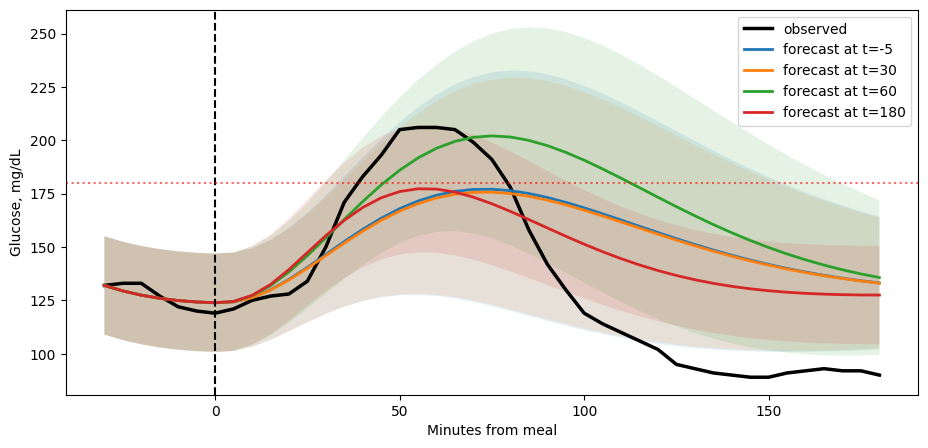

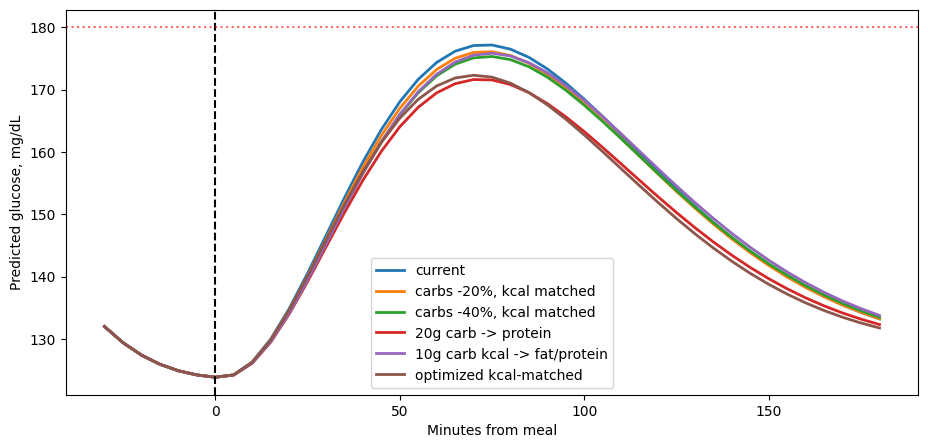

In [ ]:
# =========================================================
# Minimal End-to-End Demo
# =========================================================

RUN_MINIMAL_DEMO = True

if RUN_MINIMAL_DEMO:
    raw_df, windows = load_live_windows()
    train_idx, test_idx = split_meals_by_person(windows, random_state=1)

    # Exclude standardized test meals from model discovery.
    train_idx = [idx for idx in train_idx if not is_standardized_test_meal(windows[idx])]
    test_idx = [idx for idx in test_idx if not is_standardized_test_meal(windows[idx])]

    # 1) Coarse completed-meal labels under default kinetics.
    coarse_labels = estimate_at_labels(windows, train_idx, max_meals=60, random_state=2)

    # 2) Fit population/person kinetics from those labels.
    population_theta, person_thetas, kinetic_df, _ = fit_population_and_person_kinetics(
        windows,
        coarse_labels,
        min_person_meals=4,
    )

    # 3) Refit completed-meal A/T labels using learned kinetics.
    refined_labels = estimate_at_labels(
        windows,
        train_idx,
        theta_by_person=person_thetas,
        population_theta=population_theta,
        max_meals=120,
        random_state=3,
    )

    # 4) Fit the premeal prior p(A,T | meal + premeal state + person).
    prior_model = fit_at_prior(windows, refined_labels, l2=5.0)


Windows: 1964
Train/test: 1222 542
Population theta: {'period': 175.355, 'zeta': 0.719}
Prior A/T: 0.1702 104.8
Final A/T: {'A_mean': 0.20712812864167957, 'T_mean': 69.26808011503235, 'A_sd': 0.04581237855119989, 'T_sd': 12.874709346965355, 'A_map': 0.2103761230326362, 'T_map': 70.0, 'posterior_entropy': 4.446834879212311}
Premeal RMSE: 25.24282465670906
Online RMSE: 10.216213027972165


,candidate,carbs,fat,protein,kcal,energy_delta_kcal,A_prior,T_prior,peak,peak_delta,iAUC,time_above_180,score
0,optimized kcal-matched,40.315,27.320755,38.188301,559.9,0.0,0.163307,103.371271,191.831809,71.831809,7552.014368,50.0,360.632168
1,"carbs -40%, kcal matched",43.980,26.860889,35.558000,559.9,0.0,0.163769,103.632214,192.027262,72.027262,7574.098413,50.0,361.379723
2,10g carb kcal -> fat/protein,63.300,24.522222,21.500000,559.9,0.0,0.166090,105.109561,193.028497,73.028497,7688.031906,60.0,385.229295
3,"carbs -20%, kcal matched",58.640,23.928889,27.495000,559.9,0.0,0.167399,103.532281,193.188290,73.188290,7696.434215,60.0,385.599145
4,20g carb -> protein,53.300,22.300000,36.500000,559.9,0.0,0.170478,100.782015,193.679828,73.679828,7733.106724,60.0,387.007496
5,current,73.300,22.300000,16.500000,559.9,0.0,0.168956,104.804605,193.899752,73.899752,7778.686158,60.0,388.366906


(<Figure size 1100x500 with 1 Axes>,
 <Axes: xlabel='Minutes from meal', ylabel='Predicted glucose, mg/dL'>)

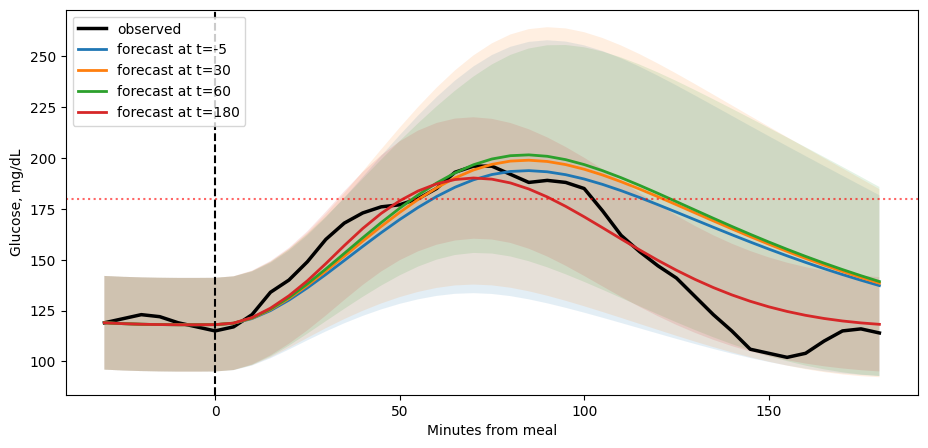

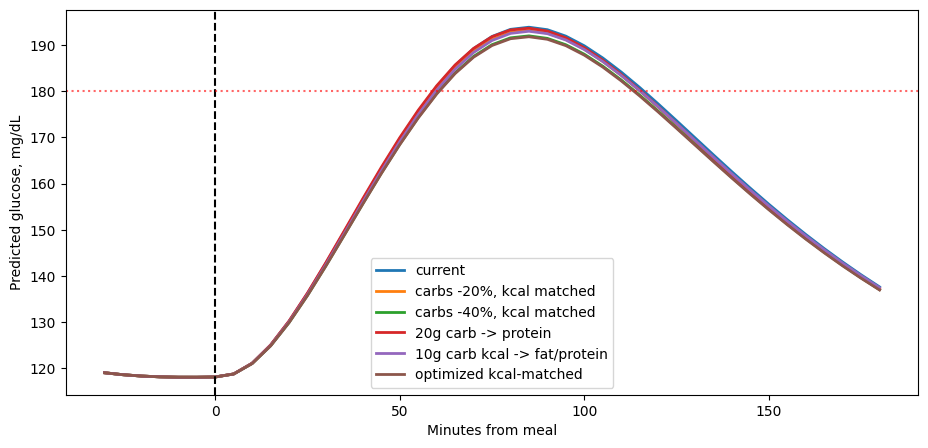

In [11]:

# 5) Run online A/T learning for one held-out meal.
sample = windows[test_idx[2]]
theta = theta_for_sample(sample, population_theta, person_thetas)
prior = predict_at_prior(sample, prior_model)
result = online_at_posterior(sample, theta=theta, prior=prior, n_A=31, n_T=31)

pre_idx = premeal_posterior_index(result["time"])
pre_pred = posterior_predictive(result, posterior_idx=pre_idx)["mean"]
final_pred = posterior_predictive(result, posterior_idx=-1)["mean"]
post = result["time"] >= 0

print("Windows:", len(windows))
print("Train/test:", len(train_idx), len(test_idx))
print("Population theta:", {k: round(population_theta[k], 3) for k in ["period", "zeta"]})
print("Prior A/T:", round(prior["A"], 4), round(prior["T"], 1))
print("Final A/T:", posterior_parameters(result, -1))
print("Premeal RMSE:", np.sqrt(np.mean((pre_pred[post] - sample["glucose"][post]) ** 2)))
print("Online RMSE:", np.sqrt(np.mean((final_pred[post] - sample["glucose"][post]) ** 2)))

plot_online_forecast(result)
display(recommend_meal(sample, theta, prior_model, n_A=21, n_T=21))
plot_counterfactuals(sample, theta, prior_model, n_A=21, n_T=21)